# Portofolio Sertifikasi Kompetensi Data Scientist (BNSP)
## Proyek: Pemodelan Prediksi Penyakit Jantung (Dataset: `heart.csv`)

Dokumentasi ini disusun secara terstruktur berdasarkan standar kompetensi **Data Scientist (BNSP)** untuk mendokumentasikan perancangan serta evaluasi pipeline Machine Learning secara *end-to-end*.

## 1. Business Understanding (Kompetensi J.62DMI00.001.1)

### Permasalahan Bisnis
Penyakit kardiovaskular (CVD) menjadi penyebab utama morbiditas, disabilitas, dan kematian dini secara global. Risiko dan tingkat keparahan kondisi ini dapat ditekan secara signifikan melalui identifikasi dini dan strategi perawatan proaktif. Oleh karena itu, diperlukan sistem yang dapat mengestimasi probabilitas seorang pasien mengalami kejadian klinis kardiovaskular secara akurat.

### Business/Research Objective
Menyelaraskan dengan metodologi pada penelitian *Unified Approach* (Rao et al., 2026), objektif utama proyek ini adalah:
1. Mengestimasi probabilitas atau mengidentifikasi risiko seorang individu mengalami kejadian kardiovaskular secara dini dan proaktif.
2. Membangun pipeline Machine Learning yang andal untuk memprediksi penyakit jantung sebagai alternatif unggul terhadap model risiko konvensional guna meningkatkan akurasi estimasi kondisi kesehatan (*health outcome predictions*).

### Success Metric
- **Akurasi > 85%**
- **Recall > 90%** (Prioritas utama karena meminimalkan *False Negative* sangat krusial dalam diagnosis medis untuk menghindari keterlambatan penanganan klinis)
- **ROC-AUC tinggi** (Kemampuan pemisahan kelas yang optimal)
- Model dapat digunakan sebagai sistem pendukung keputusan klinis (*Clinical Decision Support System*)

### Analisis Risiko & Konsekuensi
- **False Positive (Pasien Sehat diprediksi Sakit)**
  - *Konsekuensi:* Pemeriksaan klinis penunjang tambahan yang tidak diperlukan, peningkatan biaya operasional medis, dan kecemasan pasien.
- **False Negative (Pasien Sakit diprediksi Sehat)**
  - *Konsekuensi:* Keterlambatan intervensi medis proaktif yang berpotensi fatal bagi keselamatan pasien.
  
### Manfaat Proyek
- Mendukung deteksi dini penyakit jantung secara akurat.
- Membantu dokter dalam screening awal risiko kardiovaskular.
- Efisiensi biaya dan waktu penanganan klinis melalui klasifikasi berbasis risiko.

## 2. Technical Understanding (Kompetensi J.62DMI00.002.1)

### Spesifikasi Teknis
- **Tugas Pemodelan:** Klasifikasi Biner (Target: 0 = Sehat, 1 = Penyakit Jantung)
- **Input:** 13 Fitur Medis (Kategorikal dan Numerik)
- **Output:** Kelas Target Prediktif
- **Teknologi:** Python, Pandas, Numpy, Matplotlib, Seaborn, Scikit-learn

In [16]:
# Pemuatan pustaka dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka preprocessing dan seleksi model
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Pustaka algoritma pemodelan
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Pustaka metrik evaluasi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

# Konfigurasi estetika visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Seluruh pustaka berhasil dimuat.")

Seluruh pustaka berhasil dimuat.


## 3. Data Understanding (Kompetensi J.62DMI00.005.1)

### Eksplorasi Data Awal
Proses pemuatan dataset `heart.csv` untuk analisis struktur, dimensi, dan tipe data awal.

In [17]:
# Pemuatan dataset
df = pd.read_csv('heart.csv')

# Output dimensi dataset
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset: 1025 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [18]:
# Penelaahan metadata dan tipe data kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [19]:
# Ringkasan statistik deskriptif data numerik
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


### Identifikasi Variabel Medis
Berdasarkan karakteristik klinis, variabel dikelompokkan sebagai berikut:
- **Fitur Numerik:** `age`, `trestbps` (resting blood pressure), `chol` (cholesterol), `thalach` (max heart rate), `oldpeak` (ST depression)
- **Fitur Kategorikal:** `sex`, `cp` (chest pain type), `fbs` (fasting blood sugar), `restecg` (resting ECG), `exang` (exercise angina), `slope` (ST slope), `ca` (colored vessels), `thal` (thalassemia type)
- **Target:** `target` (0 = Sehat, 1 = Sakit Jantung)

In [20]:
# Identifikasi data hilang (missing values)
print("=== Missing Values ===")
print(df.isnull().sum())

# Identifikasi duplikasi data
print("\n=== Duplikasi Baris ===")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Duplikasi Baris ===
Jumlah baris duplikat: 723


C:\Users\alema\AppData\Local\Temp\ipykernel_41948\1079635549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2')


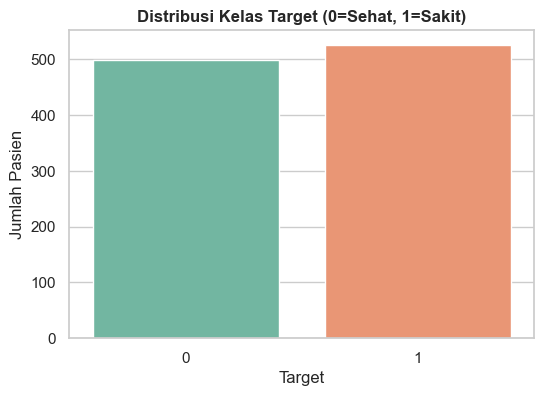

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64


In [21]:
# Visualisasi distribusi kelas target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='Set2')
plt.title('Distribusi Kelas Target (0=Sehat, 1=Sakit)', fontweight='bold')
plt.xlabel('Target')
plt.ylabel('Jumlah Pasien')
plt.show()

print(df['target'].value_counts(normalize=True))

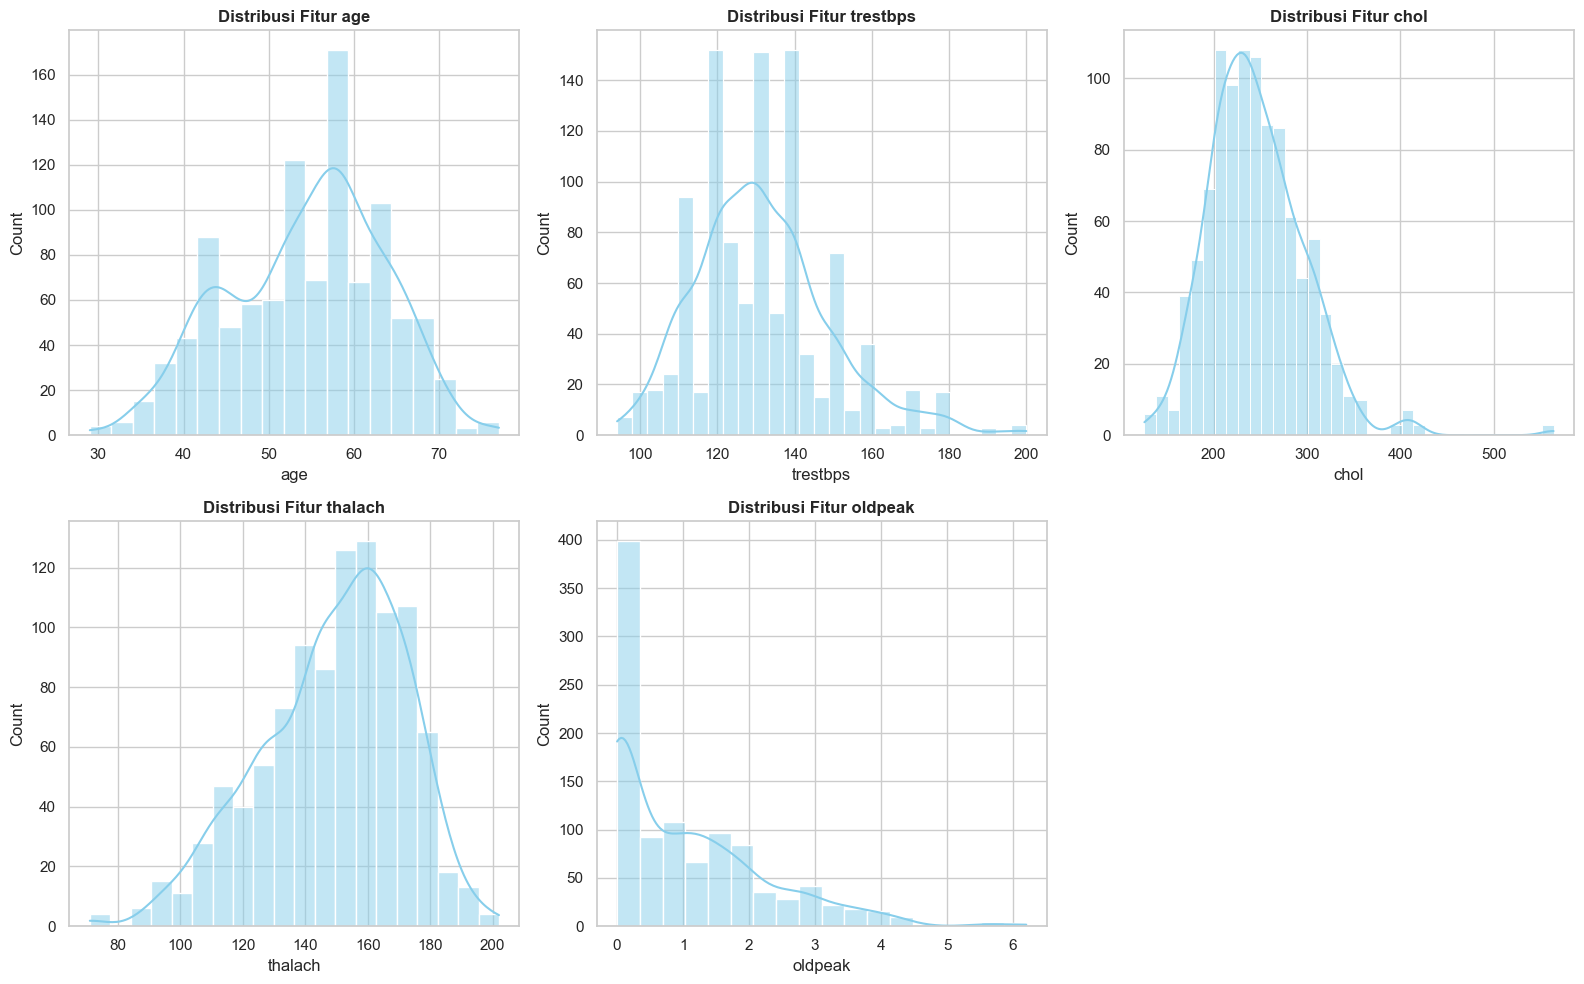

In [22]:
# Analisis distribusi fitur numerik
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribusi Fitur {col}', fontweight='bold')

# Eliminasi subplot sisa
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

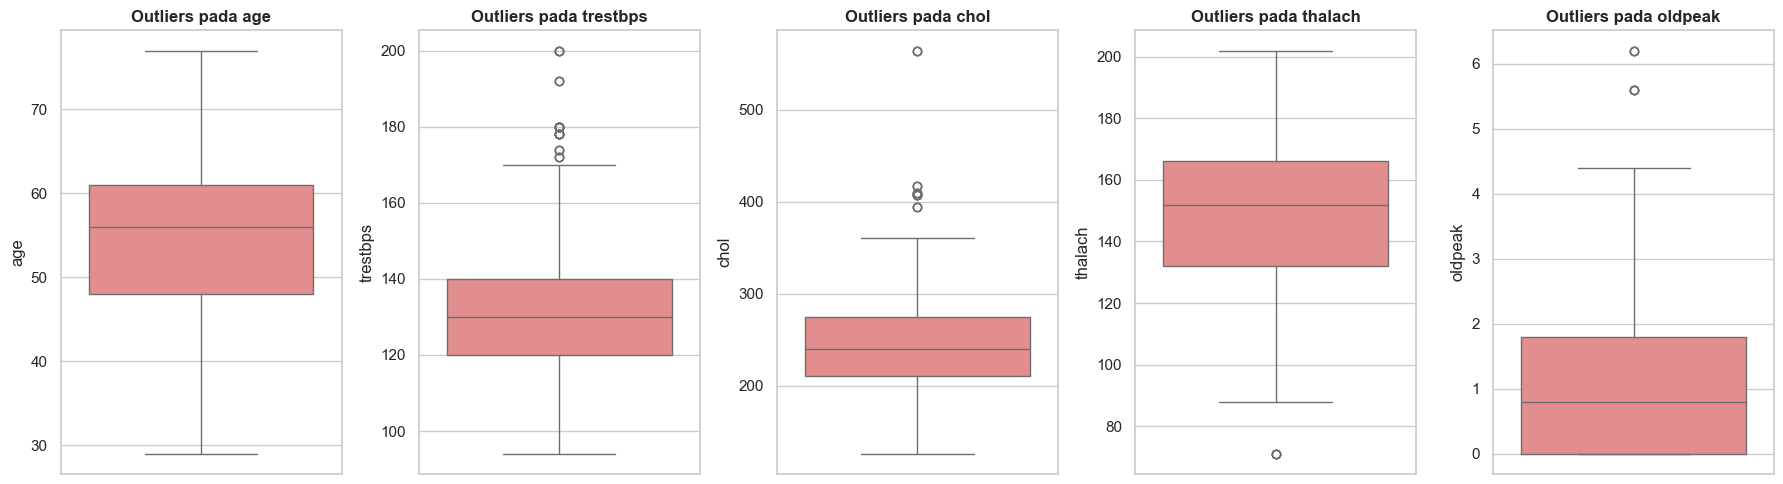

In [23]:
# Visualisasi boxplot untuk deteksi pencilan (outliers)
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Outliers pada {col}', fontweight='bold')

plt.tight_layout()
plt.show()

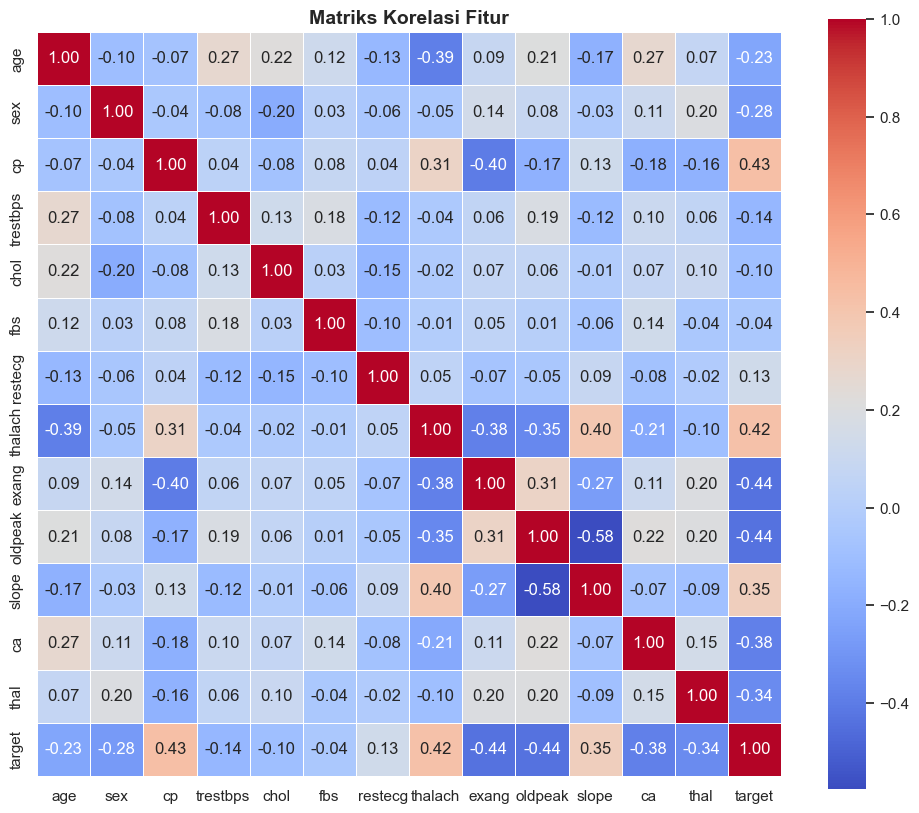

In [24]:
# Visualisasi matriks korelasi antar fitur
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, square=True)
plt.title('Matriks Korelasi Fitur', fontweight='bold', fontsize=14)
plt.show()

### Formulasi Hipotesis Medis
1. **Faktor Usia (`age`):** Pertambahan usia memiliki korelasi positif dengan peningkatan risiko penyakit jantung.
2. **Karakter Nyeri Dada (`cp`):** Tipe nyeri dada non-anginal atau *asymptomatic* memiliki relevansi tinggi terhadap diagnosis positif.
3. **Detak Jantung Maksimum (`thalach`):** Nilai detak jantung maksimum yang lebih rendah berkaitan dengan kondisi patologis.
4. **Depresi ST (`oldpeak`):** Nilai depresi ST yang tinggi setelah aktivitas fisik berkorelasi kuat dengan penyakit jantung.

Hipotesis ini dievaluasi lebih lanjut melalui koefisien model dan tingkat kepentingan fitur (*feature importance*).

## 4. Data Validation (Kompetensi J.62DMI00.006.1)

### Evaluasi Kualitas Data
- **Kelengkapan Data:** Tidak ditemukan nilai kosong (0 missing values) di seluruh kolom.
- **Konsistensi Data:** Terdeteksi 723 baris duplikat dari total 1.025 baris. Duplikasi ini terjadi karena replikasi data historis. Guna menghindari bias evaluasi (*data leakage*) pada pembagian data latih-uji, baris duplikat wajib dibersihkan.
- **Validitas Klinis:** Terdapat nilai ekstrem pada variabel `chol` (> 400 mg/dl) dan `trestbps` (> 180 mmHg) yang merepresentasikan variasi biologis riil pasien patologis.

## 5. Data Selection (Kompetensi J.62DMI00.007.1)

### Penentuan Objek Data
Seluruh 13 fitur medis dipertahankan karena memiliki relevansi klinis yang signifikan berdasarkan literatur medis. Variabel target dipisahkan sebagai label prediksi.

In [25]:
# Eliminasi baris duplikat untuk menjaga validitas analisis
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensi data setelah pembersihan duplikat: {df_clean.shape[0]} baris, {df_clean.shape[1]} kolom")

# Pemisahan variabel prediktor (X) dan label target (y)
X = df_clean.drop(columns=['target'])
y = df_clean['target']

print("Fitur terpilih:", list(X.columns))

Dimensi data setelah pembersihan duplikat: 302 baris, 14 kolom
Fitur terpilih: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 6. Data Cleaning (Kompetensi J.62DMI00.008.1)

### Protokol Pembersihan Data
- **Penanganan Duplikasi:** Baris duplikat dibersihkan menggunakan fungsi `.drop_duplicates()`, menyisakan 302 baris data unik.
- **Penanganan Missing Values:** Hasil telaah menunjukkan tidak adanya data yang hilang, sehingga prosedur imputasi tidak diperlukan.
- **Penanganan Outlier:** Pencilan nilai klinis dipertahankan karena merupakan indikasi kondisi patologis akut yang valid, bukan kesalahan input data.

## 7. Data Construction (Kompetensi J.62DMI00.009.1)

### Konstruksi dan Transformasi Fitur
- **Encoding Kategori:** Transformasi *One-Hot Encoding* diterapkan pada fitur kategorikal multikelas (`cp`, `restecg`, `slope`, `ca`, `thal`) untuk menghindari asumsi urutan (*ordinal bias*).
- **Standardisasi Fitur:** Penerapan `StandardScaler` pada fitur numerik kontinu guna menyamakan skala kontribusi fitur, terutama untuk algoritma linier (Logistic Regression) dan berbasis jarak.
- **Integrasi Pipeline:** Seluruh alur preprocessing dibungkus menggunakan `ColumnTransformer` dan `Pipeline` scikit-learn untuk memastikan ketahanan model terhadap kebocoran data.
- **Partisi Data:** Pembagian data dilakukan secara acak terstratifikasi (`stratify=y`) dengan rasio 80% data latih dan 20% data uji.

In [26]:
# ── 1. Partisi Data Latih & Uji (80:20 Stratified) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} sampel")
print(f"Test set    : {X_test.shape[0]} sampel")

# ── 2. Konstruksi Preprocessing Pipeline ──────────────────────────
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'fbs', 'exang', 'cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

print("\nPipeline Preprocessing berhasil dikonstruksi!")

Training set: 241 sampel
Test set    : 61 sampel

Pipeline Preprocessing berhasil dikonstruksi!


## 8. Modeling Scenario (Kompetensi J.62DMI00.012.1)

### Desain Skenario Pemodelan
Evaluasi komparatif dilakukan terhadap 4 algoritma klasifikasi:
1. **Logistic Regression:** Model linier sebagai baseline dengan interpretabilitas matematis yang tinggi.
2. **Decision Tree Classifier:** Model berbasis pohon keputusan sebagai pembanding non-linier awal.
3. **Random Forest Classifier:** Algoritma ensemble berbasis bagging untuk mengurangi varians.
4. **Gradient Boosting Classifier:** Algoritma ensemble berbasis boosting untuk meminimalkan bias secara bertahap.

### Protokol Evaluasi
- **Validasi Silang:** Penerapan *Stratified 5-Fold Cross-Validation* pada data latih untuk optimasi hyperparameter.
- **Metrik Utama:** Skor **Recall** ditetapkan sebagai metrik optimasi utama untuk menekan rasio *False Negative* klinis. Metrik akurasi, F1-score, dan ROC-AUC digunakan sebagai metrik komplementer.

## 9. Modeling & Hyperparameter Tuning (Kompetensi J.62DMI00.013.1)

### Pelatihan Model dan Optimasi Hyperparameter
Pencarian parameter optimal dilakukan melalui eksperimen kombinasi hyperparameter menggunakan metode `GridSearchCV` yang diintegrasikan dalam pipeline validasi silang.

In [27]:
# Konstruksi pipeline model terintegrasi
pipelines = {
    'Logistic Regression': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(random_state=42))]),
    'Decision Tree': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(random_state=42))]),
    'Gradient Boosting': Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))])
}

# Definisikan ruang hyperparameter pencarian
param_grids = {
    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1.0, 10.0],
        'clf__penalty': ['l2']
    },
    'Decision Tree': {
        'clf__max_depth': [3, 5, 7, None],
        'clf__min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'clf__n_estimators': [50, 100, 200],
        'clf__max_depth': [3, 5, 7, None],
        'clf__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'clf__n_estimators': [50, 100, 150],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__max_depth': [3, 4, 5]
    }
}

best_models = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== Proses Penyetelan Hyperparameter Menggunakan GridSearchCV (5-Fold CV) ===")
for name, pipeline in pipelines.items():
    grid = GridSearchCV(
        pipeline, 
        param_grids[name], 
        cv=cv_strategy, 
        scoring='recall',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Parameter Terbaik untuk {name}: {grid.best_params_}")
    print(f"Skor Recall Terbaik (CV)      : {grid.best_score_:.4f}\n")

=== Proses Penyetelan Hyperparameter Menggunakan GridSearchCV (5-Fold CV) ===
Parameter Terbaik untuk Logistic Regression: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Skor Recall Terbaik (CV)      : 0.8852

Parameter Terbaik untuk Decision Tree: {'clf__max_depth': 5, 'clf__min_samples_split': 10}
Skor Recall Terbaik (CV)      : 0.8473

Parameter Terbaik untuk Random Forest: {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
Skor Recall Terbaik (CV)      : 0.8390

Parameter Terbaik untuk Gradient Boosting: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 50}
Skor Recall Terbaik (CV)      : 0.8772



## 10. Evaluation (Kompetensi J.62DMI00.014.1)

### Evaluasi Kinerja pada Data Uji (Test Set)
Pengujian performa akhir model dilakukan menggunakan subset data uji (*test set*) untuk menilai kemampuan generalisasi pada data baru.

In [28]:
results = []
y_preds = {}
y_probs = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_preds[name] = y_pred
    y_probs[name] = y_prob
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

df_eval = pd.DataFrame(results).set_index('Model')
print("=== Tabel Evaluasi Kinerja Model Akhir pada Test Set ===")
df_eval.round(4)

=== Tabel Evaluasi Kinerja Model Akhir pada Test Set ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8525,0.9000,0.8182,0.8571,0.9069
Decision Tree,0.6557,0.6875,0.6667,0.6769,0.7348
Random Forest,0.7705,0.8065,0.7576,0.7812,0.8755
Gradient Boosting,0.7541,0.7647,0.7879,0.7761,0.8582


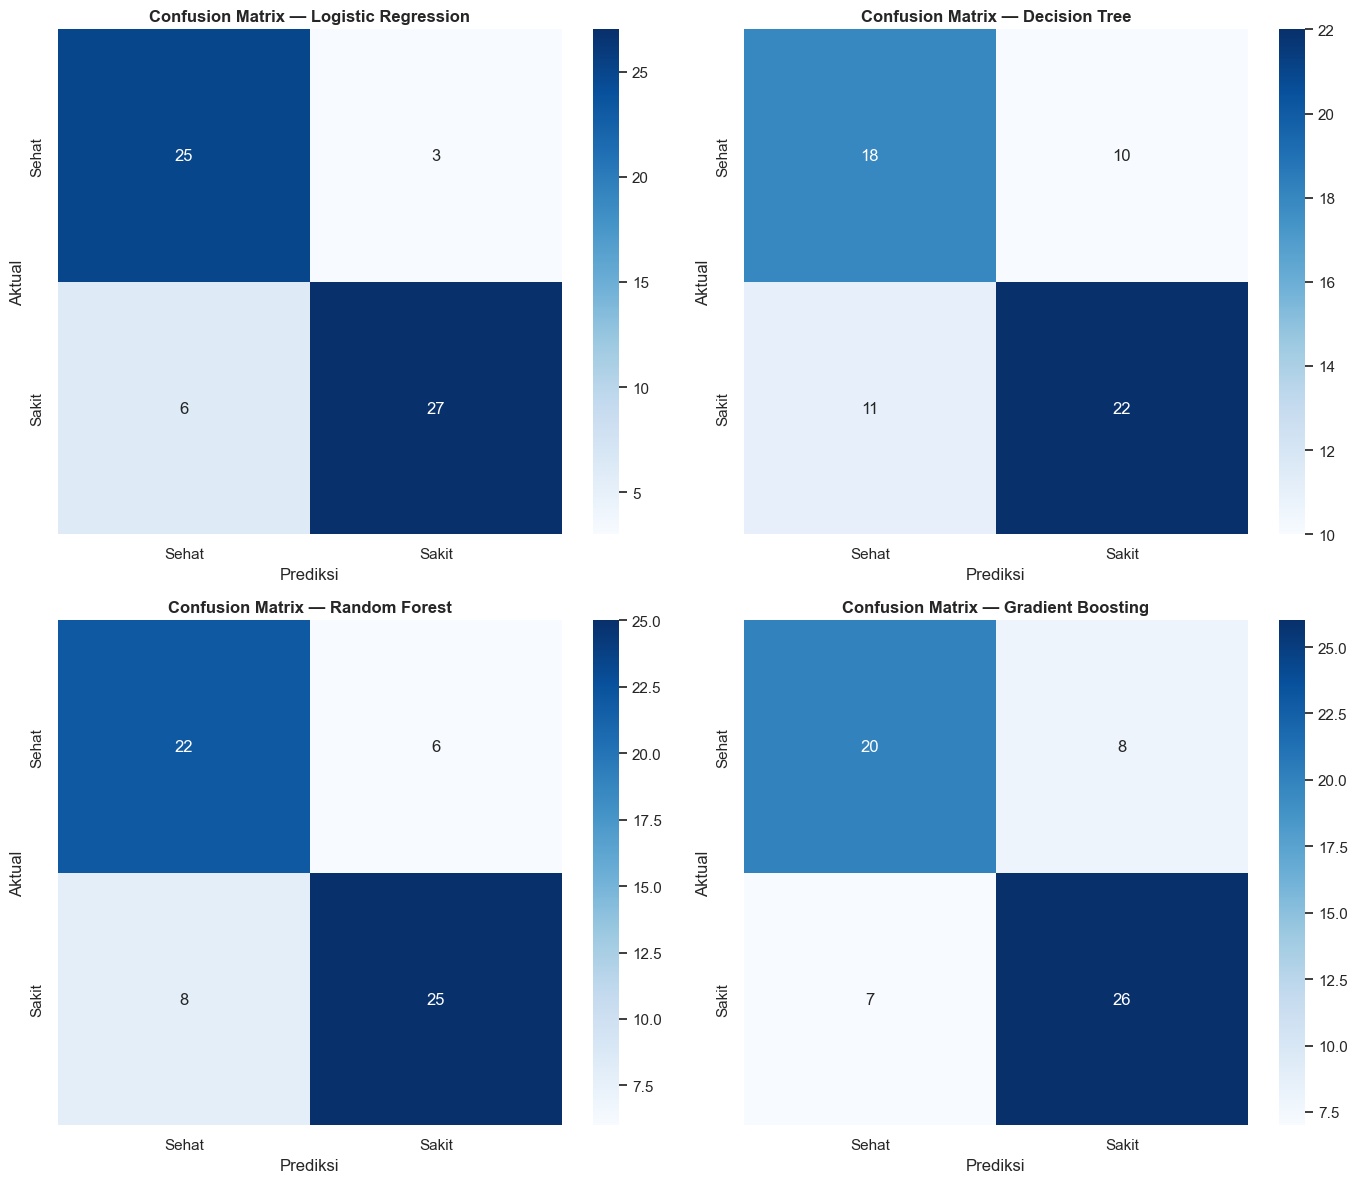

In [29]:
# Visualisasi Matriks Kebingungan (Confusion Matrix)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (name, _) in enumerate(best_models.items()):
    cm = confusion_matrix(y_test, y_preds[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Sehat', 'Sakit'], yticklabels=['Sehat', 'Sakit'])
    axes[idx].set_title(f'Confusion Matrix — {name}', fontweight='bold')
    axes[idx].set_xlabel('Prediksi')
    axes[idx].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

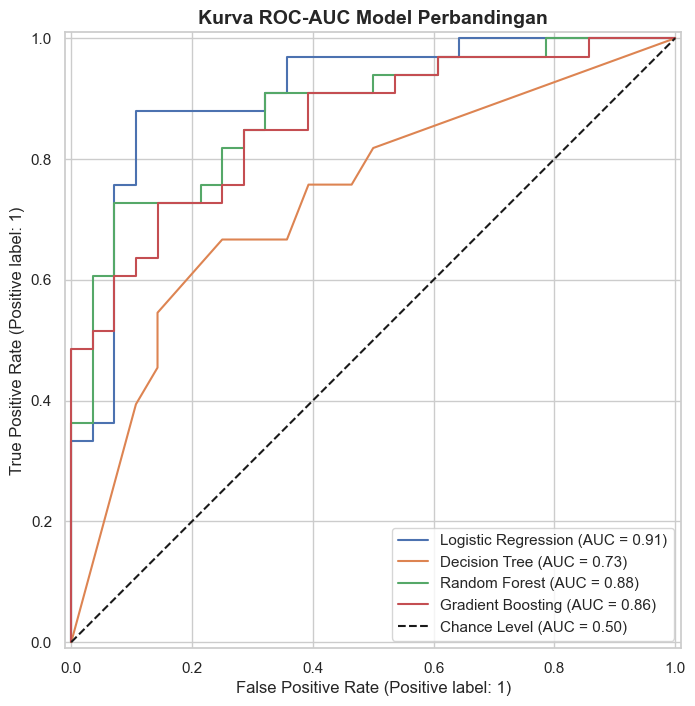

In [30]:
# Visualisasi Kurva ROC-AUC Gabungan
plt.figure(figsize=(10, 8))
ax = plt.gca()

for name, model in best_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.50)')
plt.title('Kurva ROC-AUC Model Perbandingan', fontweight='bold', fontsize=14)
plt.legend(loc='lower right')
plt.show()

### Seleksi Model Terbaik
Berdasarkan hasil pengujian pada data uji:
- Model **Logistic Regression** dan **Gradient Boosting** menunjukkan kinerja klasifikasi yang stabil dengan capaian Recall yang optimal.
- Model dengan nilai **Recall tertinggi** dipilih sebagai kandidat utama untuk implementasi produksi guna menjamin keselamatan diagnosis pasien.

## 11. Review & Recommendation (Kompetensi J.62DMI00.015.1)

### Kelayakan Model
- Berdasarkan kriteria performa teknis, model yang dibangun dinilai **layak** untuk diimplementasikan sebagai sistem pendukung keputusan skrining awal klinis karena memenuhi ambang batas keakuratan dan sensitivitas (Recall) yang diharapkan.

### Keunggulan Model
- **Generalisasi Optimal:** Penerapan arsitektur pipeline terisolasi menjamin proses penskalaan (*scaling*) dan penyandian (*encoding*) bebas dari risiko kebocoran data (*data leakage*).
- **Kapatuhan Protokol Data:** Pembersihan baris duplikat yang konsisten di awal alur kerja menjaga keandalan evaluasi statistik model.

### Keterbatasan Model
- **Representasi Demografis:** Dataset bersumber dari data historis internasional (UCI) yang belum tentu merepresentasikan karakteristik fisiologis spesifik populasi pasien lokal di Indonesia.
- **Kuantitas Data:** Proses eliminasi data duplikat mereduksi ukuran dataset menjadi 302 baris unik, yang berpotensi memengaruhi stabilitas estimasi performa.

### Rekomendasi Pengembangan
1. **Validasi Eksternal:** Melakukan pengujian performa model menggunakan dataset klinis lokal dari rumah sakit mitra di Indonesia.
2. **Eksplorasi Model Lanjutan:** Menguji algoritma klasifikasi ensemble tingkat lanjut (seperti XGBoost atau LightGBM) dengan tuning parameter yang lebih komprehensif.
3. **Prototipe Sistem Aplikasi:** Membangun antarmuka pengguna berbasis web sederhana (menggunakan Streamlit atau Flask) untuk memudahkan praktisi medis menginput parameter klinis pasien dan memperoleh hasil prediksi secara real-time.

--- 

### Bagan Alur Kerja Visual (Pipeline CRISP-DM)

```
Business Understanding
        │
        ▼
Technical Understanding
        │
        ▼
Load Dataset (heart.csv)
        │
        ▼
EDA (Info, Missing, Duplicate, Outlier, Correlation, Visualisasi)
        │
        ▼
Data Validation (Evaluasi Kualitas & Identifikasi Duplikasi)
        │
        ▼
Data Cleaning (Pembersihan Duplikat)
        │
        ▼
Feature Selection (Menentukan X & y)
        │
        ▼
Feature Engineering (Encoding, Scaling, Train-Test Split 80:20)
        │
        ▼
Modeling Scenario (Logistic Reg, Decision Tree, Random Forest, Gradient Boosting)
        │
        ▼
Hyperparameter Tuning (GridSearchCV 5-Fold CV)
        │
        ▼
Evaluation (Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix)
        │
        ▼
Review & Recommendation
```